In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.tree import plot_tree
from sklearn.inspection import PartialDependenceDisplay

In [2]:
df = pd.read_csv("C:\\Users\\Tony\\Documents\\GitHub\\EAE-598-Project\\final_all_events.csv")
df['vort_def'] =  df['rel_vort_1000'] / df['total_deformation_1000']
df['low_level_pv'] = (df['pv_925'] + df['pv_850']) / 2

In [3]:
# Random seed
zid = 1895595

# Splt the data 
train_val_df, test_df = train_test_split(df, test_size=0.2, random_state=zid)
train_df, val_df = train_test_split(train_val_df, test_size=0.125, random_state=zid)

# Print the shapes of the subsets
print("Training set shape:", train_df.shape)
print("Validation set shape:", val_df.shape)
print("Testing set shape:", test_df.shape)

Training set shape: (70, 68)
Validation set shape: (10, 68)
Testing set shape: (20, 68)


Best model configuration based on the results in the previous notebook, rf_model_configuration.ipynb

In [4]:
# Define the model parameters
n_estimators = 100
max_depth = None
min_samples_split = 2
min_samples_leaf = 1

Defined function to train and test the model

In [5]:
def train_and_evaluate_rf(train_df, test_df, var1, var2, var3, label_col, random_state, 
                          n_estimators=100, max_depth=None, min_samples_split=2, min_samples_leaf=1):
    """
    Train a Random Forest classifier and evaluate it.

    Parameters
    ----------
    train_df : pd.DataFrame
        DataFrame containing the training data.
    test_df : pd.DataFrame
        DataFrame containing the testing data.
    var1 : str
        Name of the first variable to use for training.
    var2 : str  
        Name of the second variable to use for training.
    var3 : str
        Name of the third variable to use for training.
    label_col : str
        Name of the column containing the labels.
    random_state : int
        Random seed.
    n_estimators : int, optional
        The number of trees in the forest (default is 100).
    max_depth : int, optional
        The maximum depth of the tree (default is None).
    min_samples_split : int, optional
        The minimum number of samples required to split an internal node (default is 2).
    min_samples_leaf : int, optional
        The minimum number of samples required to be at a leaf node (default is 1).

    Returns
    -------
    None

    """
    # Subset the training df to only keep the columns of the defined variables
    subset_train = train_df[[var1, var2, var3]]

    # Create a random forest classifier with the specified parameters
    rf_clf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, 
                                     min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf, 
                                     random_state=random_state)

    # Train the random forest using the data from the variables as well as the labels
    rf_clf.fit(subset_train.values, train_df[label_col].values)

    # Subset the validating df to only keep the columns of the defined variables
    test_data = test_df[[var1, var2, var3]]

    # Use the random forest with the three variables' data for the predictions
    predicted = rf_clf.predict(test_data.values)

    # Get the expected labels
    expected = test_df[label_col].values

    # Generate the classification report
    classification_report = metrics.classification_report(expected, predicted)

    print(f"Classification report for classifier {rf_clf}:\n{classification_report}\n")

We ran the Python version of this Jupyter Notebook on an HPC to evaluate all possible three-variable combinations, exceeding 38,000 combinations. The script returned a.csv file with the top 50 combinations based on overall model performance. In this notebook, we’ll take a closer look at the top 10 or so for further analysis

First, let's read in that .csv file using Pandas

In [6]:
best_vars_df = pd.read_csv("C:\\Users\\Tony\\Desktop\\top_50_variable_triplets.csv")
best_vars_df[0:15] # print the first 15 rows

,Var1,Var2,Var3,Precision,Recall,Accuracy
0,t_850,ivt,t_grad_850,1.000,1.0,1.0
1,pv_1000,ivt,tadv_925,1.000,1.0,1.0
2,pv_700,ivt,tadv_925,1.000,1.0,1.0
3,pv_300,ivt,tadv_925,1.000,1.0,1.0
4,pv_850,ivt,tadv_925,1.000,1.0,1.0
5,pv_925,ivt,tadv_925,1.000,1.0,1.0
6,q_850,ivt,t_grad_850,1.000,1.0,1.0
7,ivt,tadv_925,shearing_deformation_925,0.925,0.9,0.9
8,t_850,total_deformation_850,shearing_deformation_925,0.925,0.9,0.9
9,z_250,total_deformation_850,shearing_deformation_925,0.925,0.9,0.9


Let's make a basic plot that displays the variable frequency in the combinations to see which are best at separating MFW events from nonMFW events

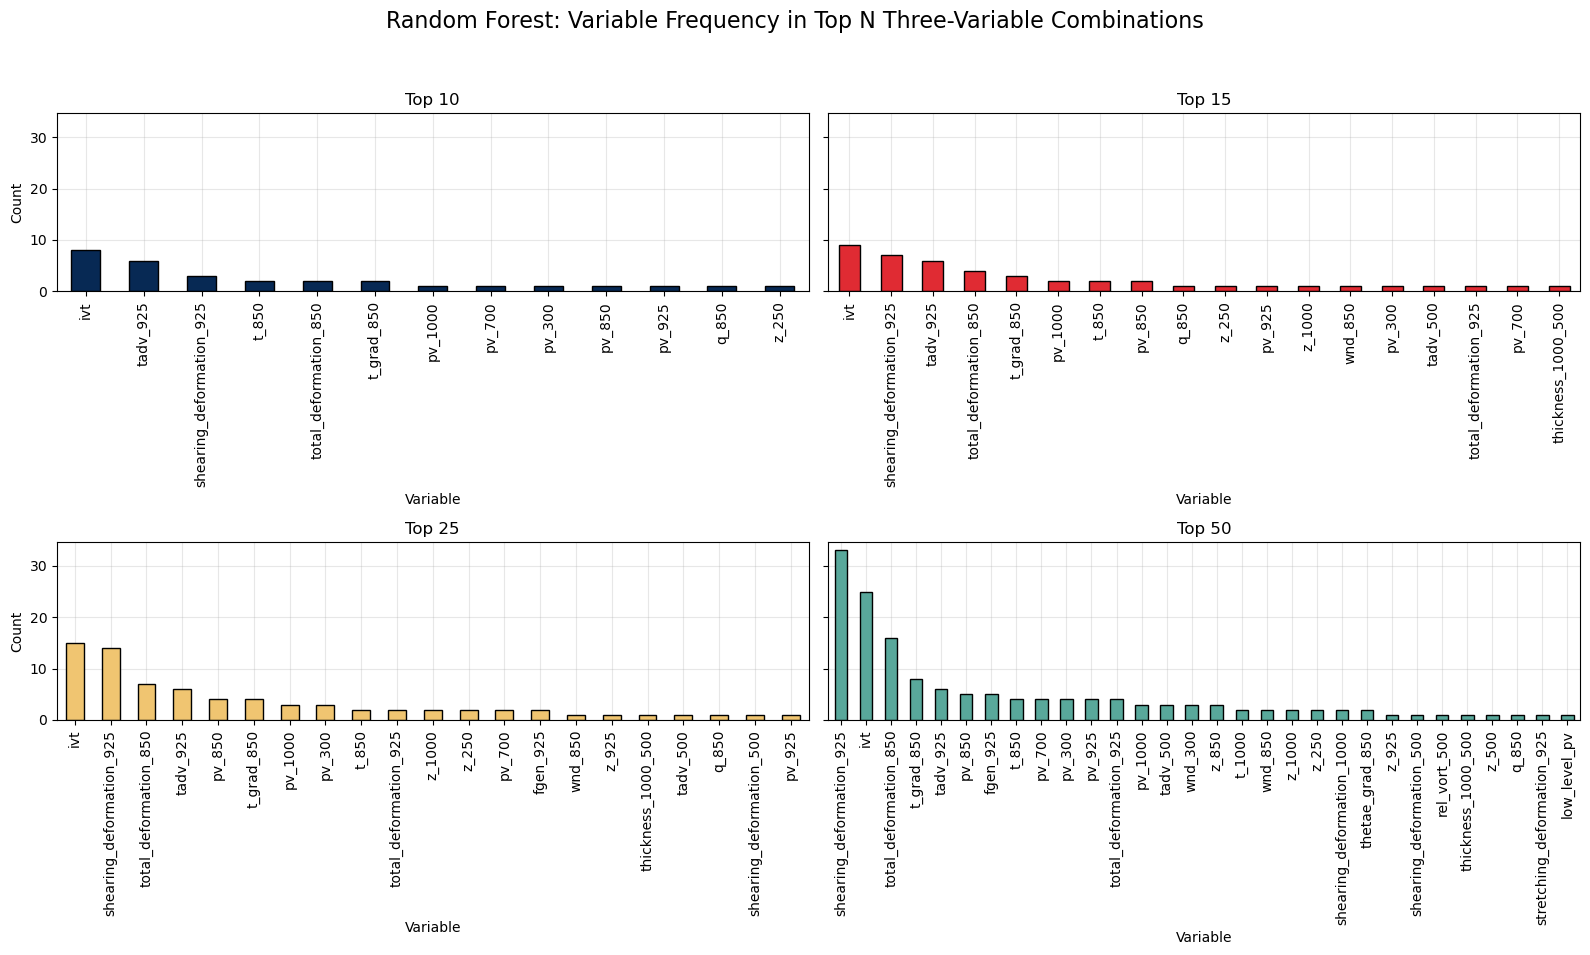

In [27]:
top_n_values = [10, 15, 25, 50]
color_map = {
    10: '#072954',
    15: '#e02b33',
    25: '#f0c571',
    50: '#59a89b'}

variable_counts = {}
for top_n in top_n_values:
    top_n_df = best_vars_df.head(top_n)
    counts = pd.concat([top_n_df['Var1'], top_n_df['Var2'], top_n_df['Var3']]).value_counts()
    variable_counts[top_n] = counts

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 10), sharex=False, sharey=True)

counts_10 = variable_counts[10]
counts_10.plot(kind='bar', ax=ax1, color=color_map[10], zorder=2, edgecolor='black')
ax1.set_title("Top 10", fontsize=12)
ax1.set_xlabel("Variable")
ax1.set_ylabel("Count")
ax1.grid(alpha=0.3, zorder=1)
ax1.tick_params(axis='x', rotation=90)

counts_15 = variable_counts[15]
counts_15.plot(kind='bar', ax=ax2, color=color_map[15], zorder=2, edgecolor='black')
ax2.set_title("Top 15", fontsize=12)
ax2.set_xlabel("Variable")
ax2.grid(alpha=0.3, zorder=1)
ax2.tick_params(axis='x', rotation=90)

counts_25 = variable_counts[25]
counts_25.plot(kind='bar', ax=ax3, color=color_map[25], zorder=2, edgecolor='black')
ax3.set_title("Top 25", fontsize=12)
ax3.set_xlabel("Variable")
ax3.set_ylabel("Count")
ax3.grid(alpha=0.3, zorder=1)
ax3.tick_params(axis='x', rotation=90)

counts_50 = variable_counts[50]
counts_50.plot(kind='bar', ax=ax4, color=color_map[50], zorder=2, edgecolor='black')
ax4.set_title("Top 50", fontsize=12)
ax4.set_xlabel("Variable")
ax4.grid(alpha=0.3, zorder=1)
ax4.tick_params(axis='x', rotation=90)

plt.suptitle("Random Forest: Variable Frequency in Top N Three-Variable Combinations", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Figure analysis:

Top 10: 
- IVT
- 925-hPa temperature advection
- 925-hPa shearing deformation 

Top 15: 
- IVT
- 925-hPa shearing deformation 
- 925-hPa temperature advection

Top 25: 
- IVT
- 925-hPa shearing deformation 
- 925-hPa total deformation 

Top 50: 
- 925-hPa shearing deformation
- IVT
- 850-hPa total deformation 

Let's try the first 10 variable combinations or so

In [8]:
var_1 = "ivt"
var_2 = "tadv_925"
var_3 = "shearing_deformation_925"

In [9]:
train_and_evaluate_rf(
    train_df=train_df,
    test_df=test_df,
    var1=var_1,
    var2=var_2,
    var3=var_3,
    label_col="label",
    random_state=zid,
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf)

Classification report for classifier RandomForestClassifier(random_state=1895595):
              precision    recall  f1-score   support

         MFW       1.00      0.90      0.95        10
       noMFW       0.91      1.00      0.95        10

    accuracy                           0.95        20
   macro avg       0.95      0.95      0.95        20
weighted avg       0.95      0.95      0.95        20




Wow - that combination is very good at separating events

Let's try a few others

In [10]:
var_1 = "ivt"
var_2 = "tadv_925"
var_3 = "total_deformation_850"

train_and_evaluate_rf(
    train_df=train_df,
    test_df=test_df,
    var1=var_1,
    var2=var_2,
    var3=var_3,
    label_col="label",
    random_state=zid,
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf)

Classification report for classifier RandomForestClassifier(random_state=1895595):
              precision    recall  f1-score   support

         MFW       1.00      0.80      0.89        10
       noMFW       0.83      1.00      0.91        10

    accuracy                           0.90        20
   macro avg       0.92      0.90      0.90        20
weighted avg       0.92      0.90      0.90        20




Not as good as the previous combination but still good!

Let's do one more

In [11]:
var_1 = "t_850"
var_2 = "tadv_850"
var_3 = "t_grad_850"

train_and_evaluate_rf(
    train_df=train_df,
    test_df=test_df,
    var1=var_1,
    var2=var_2,
    var3=var_3,
    label_col="label",
    random_state=zid,
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf)

Classification report for classifier RandomForestClassifier(random_state=1895595):
              precision    recall  f1-score   support

         MFW       1.00      0.80      0.89        10
       noMFW       0.83      1.00      0.91        10

    accuracy                           0.90        20
   macro avg       0.92      0.90      0.90        20
weighted avg       0.92      0.90      0.90        20




A little rough to say the least

Okay, now let's use the variable combinations with the highest estimated accuracy statistics 

First variable combination

In [12]:
var_1 = "t_850"
var_2 = "ivt"
var_3 = "t_grad_850"

train_and_evaluate_rf(
    train_df=train_df,
    test_df=test_df,
    var1=var_1,
    var2=var_2,
    var3=var_3,
    label_col="label",
    random_state=zid,
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf)

Classification report for classifier RandomForestClassifier(random_state=1895595):
              precision    recall  f1-score   support

         MFW       1.00      0.80      0.89        10
       noMFW       0.83      1.00      0.91        10

    accuracy                           0.90        20
   macro avg       0.92      0.90      0.90        20
weighted avg       0.92      0.90      0.90        20




Second variable combination

In [13]:
var_1 = "pv_1000"
var_2 = "ivt"
var_3 = "tadv_925"

train_and_evaluate_rf(
    train_df=train_df,
    test_df=test_df,
    var1=var_1,
    var2=var_2,
    var3=var_3,
    label_col="label",
    random_state=zid,
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf)

Classification report for classifier RandomForestClassifier(random_state=1895595):
              precision    recall  f1-score   support

         MFW       1.00      0.80      0.89        10
       noMFW       0.83      1.00      0.91        10

    accuracy                           0.90        20
   macro avg       0.92      0.90      0.90        20
weighted avg       0.92      0.90      0.90        20




Third variable combination

In [14]:
var_1 = "pv_700"
var_2 = "ivt"
var_3 = "tadv_925"

train_and_evaluate_rf(
    train_df=train_df,
    test_df=test_df,
    var1=var_1,
    var2=var_2,
    var3=var_3,
    label_col="label",
    random_state=zid,
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf)

Classification report for classifier RandomForestClassifier(random_state=1895595):
              precision    recall  f1-score   support

         MFW       1.00      0.80      0.89        10
       noMFW       0.83      1.00      0.91        10

    accuracy                           0.90        20
   macro avg       0.92      0.90      0.90        20
weighted avg       0.92      0.90      0.90        20




Fourth variable combination

In [15]:
var_1 = "pv_300"
var_2 = "ivt"
var_3 = "tadv_925"

train_and_evaluate_rf(
    train_df=train_df,
    test_df=test_df,
    var1=var_1,
    var2=var_2,
    var3=var_3,
    label_col="label",
    random_state=zid,
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf)

Classification report for classifier RandomForestClassifier(random_state=1895595):
              precision    recall  f1-score   support

         MFW       1.00      0.80      0.89        10
       noMFW       0.83      1.00      0.91        10

    accuracy                           0.90        20
   macro avg       0.92      0.90      0.90        20
weighted avg       0.92      0.90      0.90        20




Fifth variable combination

In [16]:
var_1 = "pv_850"
var_2 = "ivt"
var_3 = "tadv_925"

train_and_evaluate_rf(
    train_df=train_df,
    test_df=test_df,
    var1=var_1,
    var2=var_2,
    var3=var_3,
    label_col="label",
    random_state=zid,
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf)

Classification report for classifier RandomForestClassifier(random_state=1895595):
              precision    recall  f1-score   support

         MFW       1.00      0.80      0.89        10
       noMFW       0.83      1.00      0.91        10

    accuracy                           0.90        20
   macro avg       0.92      0.90      0.90        20
weighted avg       0.92      0.90      0.90        20




Sixth variable combination

In [17]:
var_1 = "pv_925"
var_2 = "ivt"
var_3 = "tadv_925"

train_and_evaluate_rf(
    train_df=train_df,
    test_df=test_df,
    var1=var_1,
    var2=var_2,
    var3=var_3,
    label_col="label",
    random_state=zid,
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf)

Classification report for classifier RandomForestClassifier(random_state=1895595):
              precision    recall  f1-score   support

         MFW       1.00      0.80      0.89        10
       noMFW       0.83      1.00      0.91        10

    accuracy                           0.90        20
   macro avg       0.92      0.90      0.90        20
weighted avg       0.92      0.90      0.90        20




Seventh variable combination

In [18]:
var_1 = "q_850"
var_2 = "ivt"
var_3 = "t_grad_850"

train_and_evaluate_rf(
    train_df=train_df,
    test_df=test_df,
    var1=var_1,
    var2=var_2,
    var3=var_3,
    label_col="label",
    random_state=zid,
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf)

Classification report for classifier RandomForestClassifier(random_state=1895595):
              precision    recall  f1-score   support

         MFW       1.00      0.80      0.89        10
       noMFW       0.83      1.00      0.91        10

    accuracy                           0.90        20
   macro avg       0.92      0.90      0.90        20
weighted avg       0.92      0.90      0.90        20




Eighth variable combination

In [19]:
var_1 = "shearing_deformation_925"
var_2 = "ivt"
var_3 = "t_grad_850"

train_and_evaluate_rf(
    train_df=train_df,
    test_df=test_df,
    var1=var_1,
    var2=var_2,
    var3=var_3,
    label_col="label",
    random_state=zid,
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf)

Classification report for classifier RandomForestClassifier(random_state=1895595):
              precision    recall  f1-score   support

         MFW       1.00      0.80      0.89        10
       noMFW       0.83      1.00      0.91        10

    accuracy                           0.90        20
   macro avg       0.92      0.90      0.90        20
weighted avg       0.92      0.90      0.90        20




Ninth variable combination

In [20]:
var_1 = "t_850"
var_2 = "total_deformation_850"
var_3 = "shearing_deformation_925"

train_and_evaluate_rf(
    train_df=train_df,
    test_df=test_df,
    var1=var_1,
    var2=var_2,
    var3=var_3,
    label_col="label",
    random_state=zid,
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf)

Classification report for classifier RandomForestClassifier(random_state=1895595):
              precision    recall  f1-score   support

         MFW       1.00      0.70      0.82        10
       noMFW       0.77      1.00      0.87        10

    accuracy                           0.85        20
   macro avg       0.88      0.85      0.85        20
weighted avg       0.88      0.85      0.85        20




Tenth variable combination

In [21]:
var_1 = "z_250"
var_2 = "total_deformation_850"
var_3 = "shearing_deformation_925"

train_and_evaluate_rf(
    train_df=train_df,
    test_df=test_df,
    var1=var_1,
    var2=var_2,
    var3=var_3,
    label_col="label",
    random_state=zid,
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf)

Classification report for classifier RandomForestClassifier(random_state=1895595):
              precision    recall  f1-score   support

         MFW       1.00      0.70      0.82        10
       noMFW       0.77      1.00      0.87        10

    accuracy                           0.85        20
   macro avg       0.88      0.85      0.85        20
weighted avg       0.88      0.85      0.85        20




Let's revisit that first variable combination that was successful

In [22]:
var_1 = "t_850"
var_2 = "ivt"
var_3 = "t_grad_850"

train_and_evaluate_rf(
    train_df=train_df,
    test_df=test_df,
    var1=var_1,
    var2=var_2,
    var3=var_3,
    label_col="label",
    random_state=zid,
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf)

Classification report for classifier RandomForestClassifier(random_state=1895595):
              precision    recall  f1-score   support

         MFW       1.00      0.80      0.89        10
       noMFW       0.83      1.00      0.91        10

    accuracy                           0.90        20
   macro avg       0.92      0.90      0.90        20
weighted avg       0.92      0.90      0.90        20




Classification report for classifier RandomForestClassifier(random_state=1895595):
              precision    recall  f1-score   support

         MFW       1.00      0.80      0.89        10
       noMFW       0.83      1.00      0.91        10

    accuracy                           0.90        20
   macro avg       0.92      0.90      0.90        20
weighted avg       0.92      0.90      0.90        20




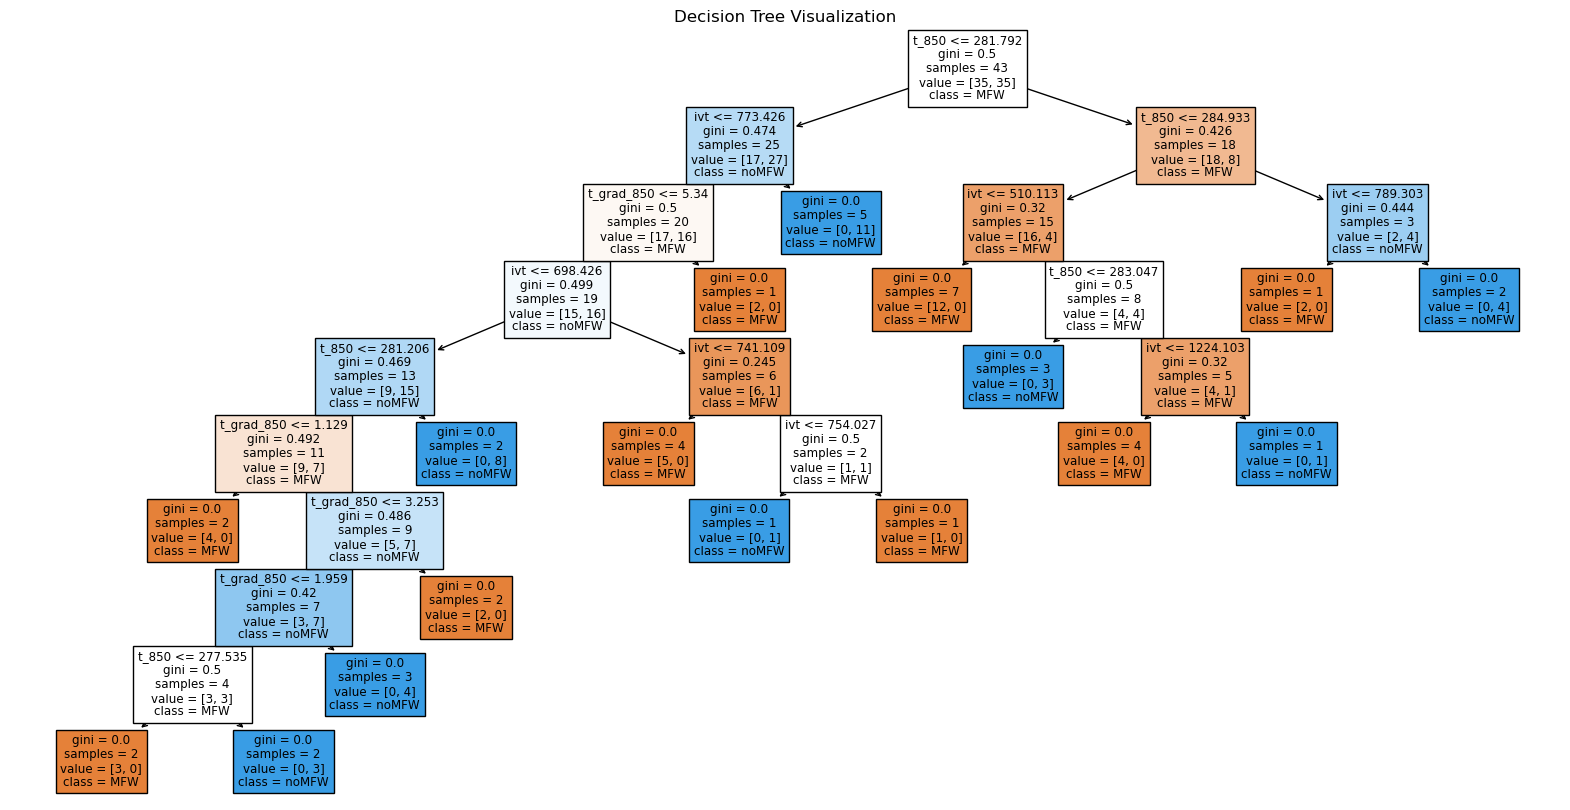

In [23]:
var_1 = "t_850"
var_2 = "ivt"
var_3 = "t_grad_850"

train_and_evaluate_rf(
    train_df=train_df,
    test_df=test_df,
    var1=var_1,
    var2=var_2,
    var3=var_3,
    label_col="label",
    random_state=zid,
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf)

rf_clf = RandomForestClassifier(
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf,
    random_state=zid)

subset_train = train_df[[var_1, var_2, var_3]]
rf_clf.fit(subset_train.values, train_df["label"].values)

plt.figure(figsize=(20, 10))
plot_tree(rf_clf.estimators_[0],feature_names=[var_1, var_2, var_3], class_names=rf_clf.classes_.astype(str), filled=True)

plt.title("Decision Tree Visualization")
plt.show()

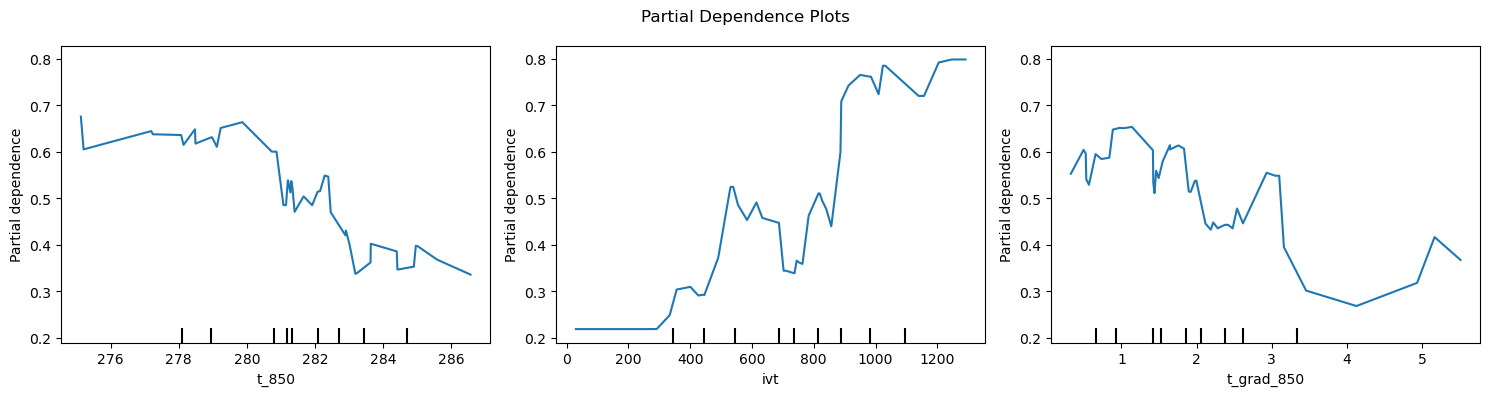

In [24]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
PartialDependenceDisplay.from_estimator(rf_clf, subset_train.values, features=[0, 1, 2],feature_names=[var_1, var_2, var_3], ax=ax)
plt.suptitle("Partial Dependence Plots")
plt.tight_layout()
plt.show()

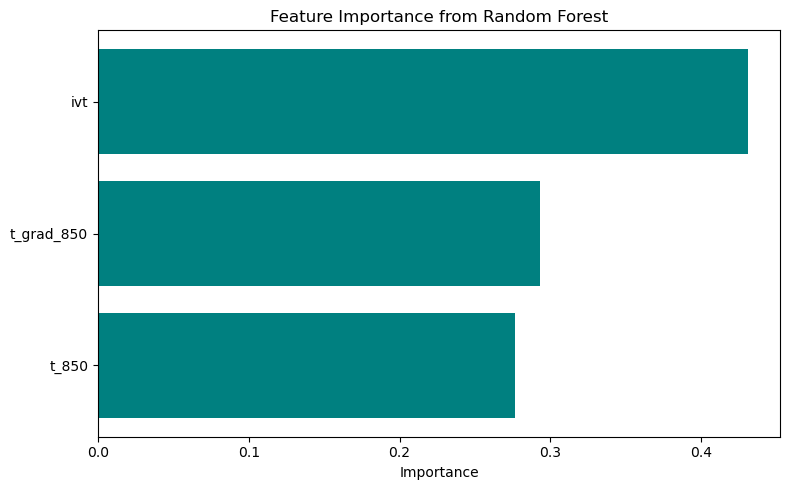

In [25]:

importances = rf_clf.feature_importances_
feature_names = [var_1, var_2, var_3]

sorted_idx = np.argsort(importances)

plt.figure(figsize=(8, 5))
plt.barh(np.array(feature_names)[sorted_idx], importances[sorted_idx], color="teal")
plt.xlabel("Importance")
plt.title("Feature Importance from Random Forest")
plt.tight_layout()
plt.show()